In [1]:
%load_ext autoreload
%aimport ComplexPlotFunction
%aimport GaussianBeamBasis
%aimport ApertureFunction
%aimport GSMaskAlgorithum
%autoreload 1

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
# Global Ploting properties and style
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = [9,9]

import ComplexPlotFunction as cmplxplt
import GaussianBeamBasis as GaussBeams
import ApertureFunction as AppFunc
import GSMaskAlgorithum as GSAlgom

# Import your coupling matrix lib here don't forget to add to cell above for live updates


# Set up some general parameters like the spatial coordinate system, wavelengt, pixel size. 

In [3]:
Nx=720
Ny=720
wavelength=820e-9
pixelSize=9.2e-6 # this is the pixel size on the SLM

xmin=(((-(Nx-1))/2.0))*pixelSize
xmax=(((Nx-1)/2.0))*pixelSize
ymin=(((-(Ny-1))/2.0))*pixelSize
ymax=(((Ny-1)/2.0))*pixelSize
xArr=np.linspace(xmin,xmax,Nx)
yArr=np.linspace(ymin,ymax,Ny)
XGrid, YGrid= np.meshgrid(xArr,yArr)

# Make the input beam and the desired output mode

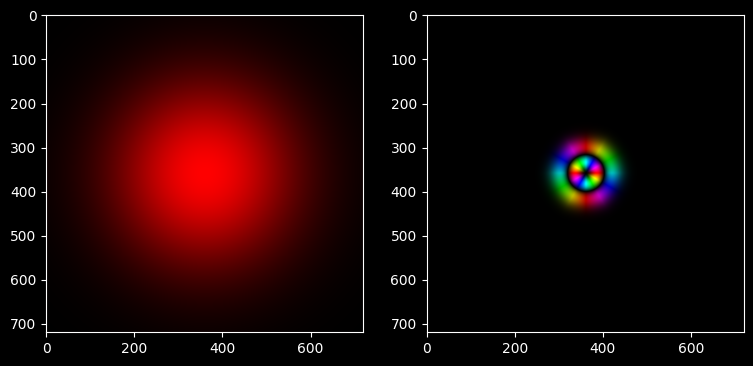

In [4]:
# This is the MFD of the input beam usually a Gaussian beam 
MFDin=3.8087178445389758e-3 # I guessed this maybe you wrote the number down

# This is working out the waist of the Gaussian in the mode group based of the camera size and the max mode in the group
MFDcam=0.5*544*6.9e-6 # size the mode will be on the camera
ModeGroup=4 # mode group you are going up to
MFDout=2*GaussBeams.wasitOfbasis(MFDcam/2,ModeGroup)


################
# This will make the input Gaussian beam
################
Field_Source = GaussBeams.GenerateLGMode(MFDin, wavelength,0,0, pixelSize,XGrid,YGrid, 0, 0)

################
# Make a HG mode of some index
################
# n=4
# m=2
# Field_target = GaussBeams.GenerateHGMode(MFDout, wavelength,n,m, pixelSize,XGrid,YGrid, 0, 0)

################
# Make a LG mode of some index
################
p=1
l=-2
Field_target = GaussBeams.GenerateLGMode(MFDout, wavelength,p,l, pixelSize,XGrid,YGrid, 0, 0)

# Plot the complex field of the input Gaussian and the desired modes
plt.figure()
plt.subplot(1,2,1)
plt.imshow(cmplxplt.ComplexArrayToRgb(Field_Source))
plt.subplot(1,2,2)
plt.imshow(cmplxplt.ComplexArrayToRgb(Field_target))



# Calculate phase mask via the GS algorithm.
### Need to make some apertures for the GS algorithm. The ApertureSize and PwrForReconMode are the nobs you have to turn. changing these values will changer the quality of the reconstructed field 

Total Power:  1.0000000000000009  Power in mode:  0.011926783388065128  Power lose:  0.011926783388065118
Overlap of Target and Reconstructed Mode:  (0.969270435726734-0.0005265450681061596j)


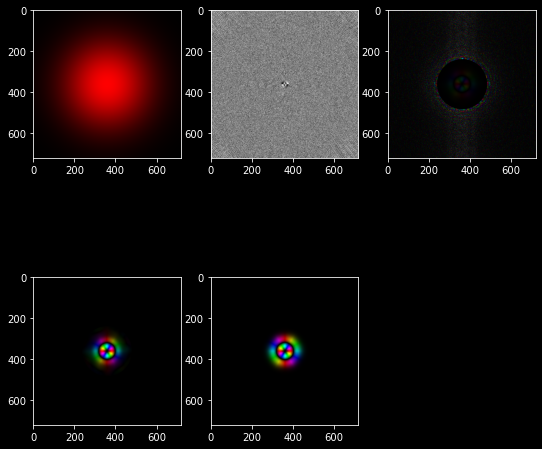

In [7]:
################
# Make some apertures for the GS algorithm. 
################
ApertureSize=np.round(1.2*(MFDcam/2)/pixelSize)# work out the 1.2 by hand it will be a parameter to optimise in 
PwrForReconMode=0.05 # This is the other free parameter it dictates how much power of the source beam will be used to reconstruct the field

Aperture_ForMode=np.zeros((Nx,Ny),dtype=complex)
Aperture_ForMode=AppFunc.circular_aperture(Aperture_ForMode, ApertureSize, Nx//2, Ny//2, 1)

Aperture_ForFreeField=np.ones((Nx,Ny),dtype=complex)
Aperture_ForFreeField=AppFunc.circular_aperture(Aperture_ForFreeField, ApertureSize, Nx//2, Ny//2, 0)
################
# if you want to look at the aperture you can uncomment the plot lines below
################
# plt.subplot(1,2,1)
# plt.imshow(cmplxplt.ComplexArrayToRgb(Aperture_ForMode))
# plt.subplot(1,2,2)
# plt.imshow(cmplxplt.ComplexArrayToRgb(Aperture_ForFreeField))

################
# Run the GS algorithm. 
# You can adjust the ItterCount value but it seems like it will generally get a solution in 50 iterations
################
PhaseMask,FarField_app,FarField,TotalPwrInFarField,PwrInReconMode = GSAlgom.GS_ComplexShaping(
    Field_target,Field_Source,Aperture_ForMode,Aperture_ForFreeField,pixelSize,PwrForReconMode,ItterCount=50)
################
#  Plot and print the results of the GS algorithm. 
################
plt.subplot(2,3,1)
plt.imshow(cmplxplt.ComplexArrayToRgb(Field_Source))
plt.subplot(2,3,2)
plt.imshow(PhaseMask,cmap='gray',vmin=-np.pi, vmax=np.pi)
plt.subplot(2,3,3)
plt.imshow(cmplxplt.ComplexArrayToRgb(FarField))
plt.subplot(2,3,4)
plt.imshow(cmplxplt.ComplexArrayToRgb(FarField_app))
plt.subplot(2,3,5)
plt.imshow(cmplxplt.ComplexArrayToRgb(Field_target))


# Make a set of modes up to some mode group of some MFD

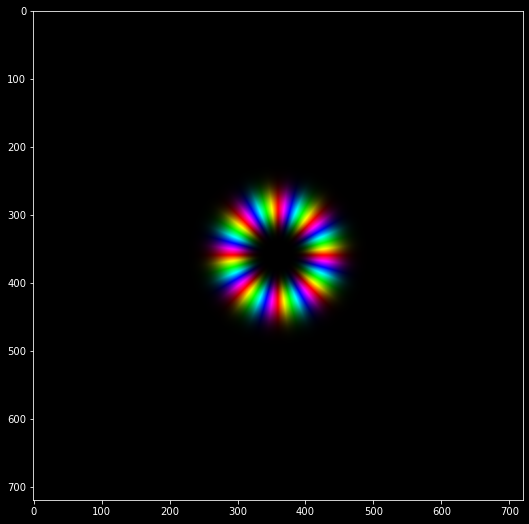

In [11]:

MFD=MFDout

maxModeGroup=9
modeCount=sum(range(1,maxModeGroup+1))
MODES=np.zeros((modeCount,Ny,Nx),dtype=np.complex128)
modeIndices=np.zeros((2,modeCount))
ModeType='LG' # Change to 'HG' if you like HG mode better then LG

imode=0
for mgIdx in range(maxModeGroup):
    #zero-based index of the mode-group
    mgIDX = mgIdx;
    #For every mode in this group (there will be mgIdx of them)
    for modeIdx in range(mgIdx+1):
        #m+n should equal mgIDX.
        #Go through each m,n combo in this group starting with max m
        n = mgIDX-(modeIdx);
        m = mgIDX-n;
        l=m-n;
        p=min([n,m]);
        if (ModeType=='LG'):
            modeIndices[0,imode]=p
            modeIndices[1,imode]=l
            MODES[imode,:,:]= GaussBeams.GenerateLGMode(MFD, wavelength,p,l, pixelSize,XGrid,YGrid, 0, 0)
        elif(ModeType=='HG'):  
            modeIndices[0,imode]=n
            modeIndices[1,imode]=m
            MODES[imode,:,:]= GaussBeams.GenerateHGMode(MFD, wavelength,n,m, pixelSize,XGrid,YGrid, 0, 0)
        imode=imode+1
        
# Plots the last mode in the group. Dont really need to do this but is there so you get an idea what the heck is in t MODES array       
plt.imshow(cmplxplt.ComplexArrayToRgb(MODES[-1,:,:]))

### Please write code to calculate masks for a set of modes, up to a specified group number (e.g., group 4 or 5). The modes will be generated in the cell above this one; you only need to specify the maximum group number and the Mode Field Diameter (MFD) of the Gaussian in the group. This MFD should match the MFDout value used in a previous example. After generating the modes, please construct a coupling matrix, which I will explain in detail later.


In [ ]:
# You masterpiece should start here